d:\anykn\python\propaganda-detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Token indices sequence length is longer than the specified maximum sequence length for this model (706 > 512). Running this sequence through the model will result in indexing errors


Analysing 371 articles...


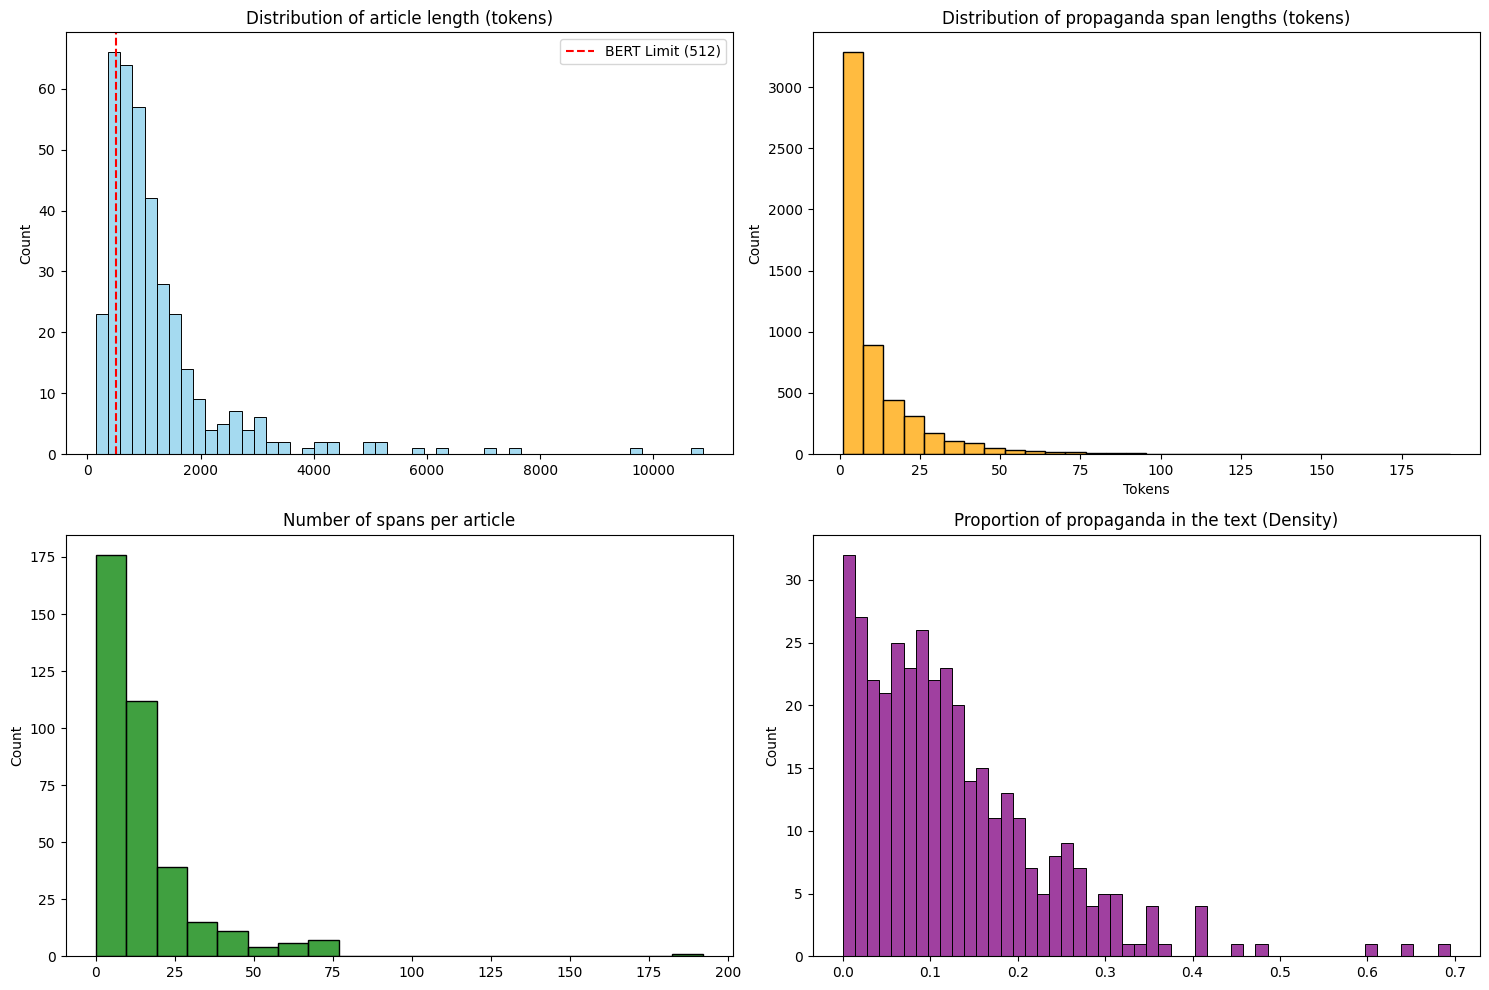


📊 --- STATS ---
Average article length: 1260.3 tokens
Articles longer than 512 tokens: 314 (84.6%)
Average number of spans per article: 14.7
Average span length: 10.9 tokens
Global Ratio: 12.6%


In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import AutoTokenizer

with open('../data/processed/si_dataset.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

article_lengths = []
propaganda_ratios = []
span_lengths_tokens = []
num_spans_per_article = []

print(f"Analysing {len(data)} articles...")

for entry in data:
    text = entry['text']
    spans = entry['spans']
    
    tokens = tokenizer.encode(text, add_special_tokens=True)
    article_len = len(tokens)
    article_lengths.append(article_len)
    
    num_spans_per_article.append(len(spans))
    
    propaganda_char_count = 0
    for span in spans:
        span_len = span['end'] - span['start']
        propaganda_char_count += span_len
        
        span_text = text[span['start']:span['end']]
        span_tokens = tokenizer.encode(span_text, add_special_tokens=False)
        span_lengths_tokens.append(len(span_tokens))

    ratio = propaganda_char_count / len(text) if len(text) > 0 else 0
    propaganda_ratios.append(ratio)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(article_lengths, bins=50, ax=axes[0, 0], color='skyblue')
axes[0, 0].axvline(512, color='red', linestyle='--', label='BERT Limit (512)')
axes[0, 0].set_title('Distribution of article length (tokens)')
axes[0, 0].legend()

sns.histplot(span_lengths_tokens, bins=30, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Distribution of propaganda span lengths (tokens)')
axes[0, 1].set_xlabel('Tokens')

sns.histplot(num_spans_per_article, bins=20, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Number of spans per article')

sns.histplot(propaganda_ratios, bins=50, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Proportion of propaganda in the text (Density)')

plt.tight_layout()
plt.show()

print(f"\n📊 --- STATS ---")
print(f"Average article length: {np.mean(article_lengths):.1f} tokens")
print(f"Articles longer than 512 tokens: {np.sum(np.array(article_lengths) > 512)} ({np.sum(np.array(article_lengths) > 512)/len(data):.1%})")
print(f"Average number of spans per article: {np.mean(num_spans_per_article):.1f}")
print(f"Average span length: {np.mean(span_lengths_tokens):.1f} tokens")
print(f"Global Ratio: {np.mean(propaganda_ratios):.1%}")

In [2]:
for article in data:
    if len(article['spans']) > 75:
        print(article['article_id'])

article763260610
article783702663


In [3]:
for article in data:
    if len(article['spans']) == 0:
        print(article['article_id'])

article111111121
article695108099
article725238842
article728153988
article729700539
article730036755
article730061195
article730652769
article754348478
article754508491
article758385628
article758469195
article758669180
article758882558


In [4]:
avg_ratio = np.mean(propaganda_ratios)
suggested_weight = (1 - avg_ratio) / avg_ratio
print(f"\nRecommended class weight (pos_weight): ~{suggested_weight:.1f}")


Recommended class weight (pos_weight): ~7.0


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split


article_densities = []
for item in data:
    text_len = len(item['text'])
    if text_len == 0:
        article_densities.append(0)
        continue
        
    prop_chars = sum([span['end'] - span['start'] for span in item['spans']])
    density = prop_chars / text_len
    article_densities.append(density)

bins = [-1, 0.0001, 0.10, 0.25, 1.0]
labels = [0, 1, 2, 3]
categories = pd.cut(article_densities, bins=bins, labels=labels)

train_data, val_data = train_test_split(
    data, 
    test_size=0.15, 
    random_state=42, 
    stratify=categories
)

def get_global_density(data_split):
    total_chars = sum([len(a['text']) for a in data_split])
    prop_chars = sum([span['end'] - span['start'] for a in data_split for span in a['spans']])
    return (prop_chars / total_chars) * 100 if total_chars > 0 else 0

print(f"Train density (Propaganda): {get_global_density(train_data):.2f}%")
print(f"Val density (Propaganda): {get_global_density(val_data):.2f}%")

Train density (Propaganda): 12.90%
Val density (Propaganda): 14.73%


📊 --- ANALYSIS OF GAPS BETWEEN SPANS ---
Total number of gaps found between different spans: 5063
Minimum gap: 1 characters
Maximum gap: 9235 characters
Average gap: 290.1 characters
Median gap: 132.0 characters

🔍 Analysis of potential tagging errors (Micro-gaps):
Gaps <= 1 characters: 63 cases (1.24%)
Gaps <= 2 characters: 299 cases (5.91%)
Gaps <= 3 characters: 375 cases (7.41%)
Gaps <= 4 characters: 421 cases (8.32%)
Gaps <= 5 characters: 461 cases (9.11%)
Gaps <= 10 characters: 594 cases (11.73%)


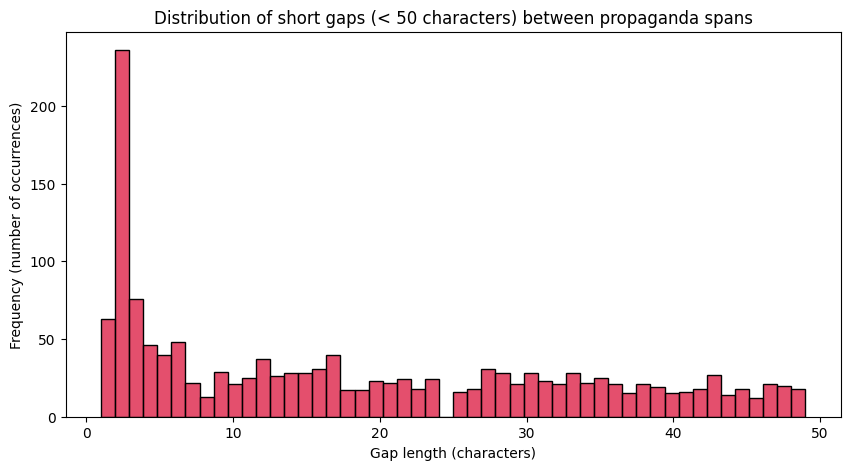

In [6]:
all_gaps = []
short_gaps = []

for entry in data:
    spans = entry['spans']
    
    sorted_spans = sorted(spans, key=lambda x: x['start'])
    
    for i in range(len(sorted_spans) - 1):
        current_span_end = sorted_spans[i]['end']
        next_span_start = sorted_spans[i+1]['start']
        
        gap = next_span_start - current_span_end
        
        if gap >= 0:
            all_gaps.append(gap)
            if gap < 50:
                short_gaps.append(gap)

all_gaps = np.array(all_gaps)

print("📊 --- ANALYSIS OF GAPS BETWEEN SPANS ---")
print(f"Total number of gaps found between different spans: {len(all_gaps)}")

if len(all_gaps) > 0:
    print(f"Minimum gap: {np.min(all_gaps)} characters")
    print(f"Maximum gap: {np.max(all_gaps)} characters")
    print(f"Average gap: {np.mean(all_gaps):.1f} characters")
    print(f"Median gap: {np.median(all_gaps):.1f} characters")
    
    print("\n🔍 Analysis of potential tagging errors (Micro-gaps):")
    for t in [1, 2, 3, 4, 5, 10]:
        count = np.sum(all_gaps <= t)
        percent = count / len(all_gaps)
        print(f"Gaps <= {t} characters: {count} cases ({percent:.2%})")

plt.figure(figsize=(10, 5))
sns.histplot(short_gaps, bins=50, color='crimson')
plt.title('Distribution of short gaps (< 50 characters) between propaganda spans')
plt.xlabel('Gap length (characters)')
plt.ylabel('Frequency (number of occurrences)')
plt.show()